# Introduction to GPyTorch

_Drew Gjerstad_

**Includes content adapted from Professor Aryan Deshwal's special topics course on AI for sequential decision making at the University of Minnesota (Spring 2026).**

In this notebook, we introduce GPyTorch: a library for defining and training Gaussian process models in Python.

## Load Dependencies

In [2]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

## Define Training Data
First, we define the training data that our model will learn. Recall that Gaussian process models assume there is noise included in each observation (measurement). Thus, you will notice that we define noise-free "true" function values and observed function values with additive noise.

In [3]:
# Set seed
torch.manual_seed(1)

# Define true function
def function(x):
    return torch.sin(2 * x)

# Define training inputs
train_x = torch.linspace(0, 3, 30)

# Define noise-free "true" function values
true_y = function(train_x)

# Define observed function values w/ additive noise
noise_std = 0.1
train_y = true_y + noise_std * torch.randn_like(train_x)

In [4]:
# Check shape
print(f"train_x Shape: {train_x.shape}")
print(f"train_y Shape: {train_y.shape}")

train_x Shape: torch.Size([30])
train_y Shape: torch.Size([30])


## Define Model
Next, we define a class which will implement our GP model. Notice that we must define class attributes and methods as follows:
 * `mean_module` should be defined in the `__init__` function. This module represents the prior mean function of our GP model.
 * `covar_module` should be defined in the `__init__` function. This module represents the prior covariance (kernel) of our GP model.
 * The `forward` function must be defined in such a manner that inputs are passed into the mean and covariance modules, and then used to return a distribution.

In [5]:
# Exact GP Model
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)

        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean = self.mean_module(x)
        covar = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean, covar)

## Build Model
With the model defined, we can now create an instance of it. Below, we also instantiate an likelihood object which represents the **observation model** for our GP model. Recall that the observation model assumes that our measurements include additive noise and incorporates a parameter for learning the noise variance during model training.

In [7]:
# Instantiate observation model (likelihood)
likelihood = gpytorch.likelihoods.GaussianLikelihood()

In [8]:
# Instantiate GP model
model = ExactGPModel(train_x, train_y, likelihood)

## Exploring Model Priors
Before we train our GP model, we can compute the prior distribution for a set of "test" inputs that our outside of the range of training inputs. Recall that a GP model effectively defines a distribution **over functions** that may represent the underlying "true" function we defined earlier. Thus, we can sample from the set of functions evaluated at our test inputs.

In [9]:
# Define test inputs
test_x = torch.linspace(-1, 4, 100)

In [10]:
# Put model in evaluation mode
model.eval()

ExactGPModel(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): ZeroMean()
  (covar_module): ScaleKernel(
    (base_kernel): RBFKernel(
      (raw_lengthscale_constraint): Positive()
    )
    (raw_outputscale_constraint): Positive()
  )
)

In [17]:
# Compute prior distribution, sample 3 random functions from prior
with torch.no_grad():
    prior_dist = model(test_x)

    prior_samples = prior_dist.rsample(sample_shape=torch.Size([3]))

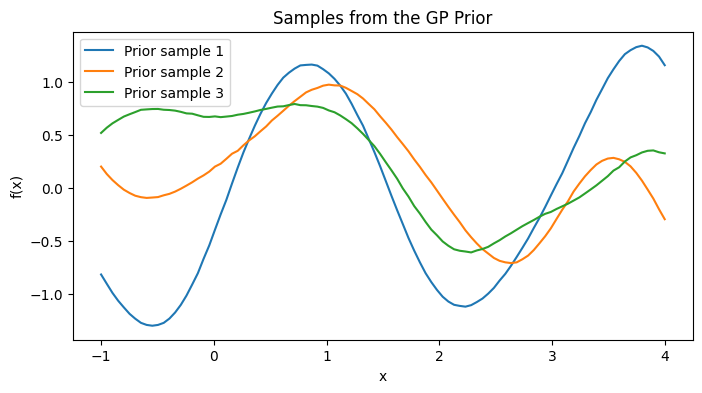

In [18]:
# Plot random samples
plt.figure(figsize=(8, 4))
for i in range(3):
    plt.plot(test_x.numpy(), prior_samples[i].numpy(), label=f'Prior sample {i+1}')
plt.title("Samples from the GP Prior")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

## Train Model
Next, we can train our model to minimize the **negative marginal log-likelihood** (the loss for GPs in GPyTorch). The goal of such minimization is to learn the function that is most likely to be the underlying function.

In [35]:
# Put model and likelihood in training mode
model.train()
likelihood.train()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [36]:
# Define optimizer
optimizer = torch.optim.Adam([
    {'params': model.parameters()}
], lr=0.1)

In [37]:
# Define loss (negative marginal log-likelihood [MLL])
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

In [38]:
# Training loop
training_iter = 2000
loss_history = []
for i in range(training_iter):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (i+1) % 100 == 0:
        print(f"Iter {i+1}/{training_iter} - Loss: {loss.item():.3f}"
              f"  lengthscale: {model.covar_module.base_kernel.lengthscale.item():3f}"
              f"  noise: {model.likelihood.noise.item():.3f}")

Iter 100/2000 - Loss: -0.407  lengthscale: 0.849429  noise: 0.010
Iter 200/2000 - Loss: -0.407  lengthscale: 0.849377  noise: 0.010
Iter 300/2000 - Loss: -0.407  lengthscale: 0.849375  noise: 0.010
Iter 400/2000 - Loss: -0.407  lengthscale: 0.849373  noise: 0.010
Iter 500/2000 - Loss: -0.407  lengthscale: 0.849385  noise: 0.010
Iter 600/2000 - Loss: -0.407  lengthscale: 0.849386  noise: 0.010
Iter 700/2000 - Loss: -0.407  lengthscale: 0.849380  noise: 0.010
Iter 800/2000 - Loss: -0.407  lengthscale: 0.849369  noise: 0.010
Iter 900/2000 - Loss: -0.407  lengthscale: 0.849381  noise: 0.010
Iter 1000/2000 - Loss: -0.407  lengthscale: 0.849389  noise: 0.010
Iter 1100/2000 - Loss: -0.407  lengthscale: 0.849381  noise: 0.010
Iter 1200/2000 - Loss: -0.407  lengthscale: 0.849387  noise: 0.010
Iter 1300/2000 - Loss: -0.407  lengthscale: 0.849385  noise: 0.010
Iter 1400/2000 - Loss: -0.407  lengthscale: 0.849352  noise: 0.010
Iter 1500/2000 - Loss: -0.407  lengthscale: 0.849363  noise: 0.010
Iter

## Evaluate Model
We can now evaluate our model and see if we were able to sufficiently learn the underlying function.

In [39]:
# Put model and likelihood in evaluation mode
model.eval()
likelihood.eval()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [40]:
# Compute predictions
with torch.no_grad():
    pred_dist = likelihood(model(test_x))
    mean = pred_dist.mean                               # prediction estimate
    lower, upper = pred_dist.confidence_region()        # prediction uncertainty bounds

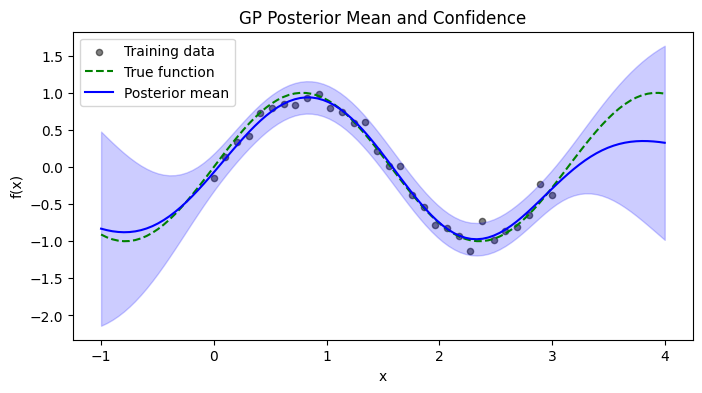

In [41]:
# Plot training data, true function, and posterior estimates
plt.figure(figsize=(8,4))

# Training data
plt.scatter(train_x.numpy(), train_y.numpy(), color='k', s=20, alpha=0.5, label="Training data")

# True function
plt.plot(test_x.numpy(), function(test_x).numpy(), 'g--', label="True function")

# Posterior mean estimates and corresponding uncertainty
plt.plot(test_x.numpy(), mean.numpy(), 'b', label="Posterior mean")
plt.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.2, color='blue')

plt.title('GP Posterior Mean and Confidence')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

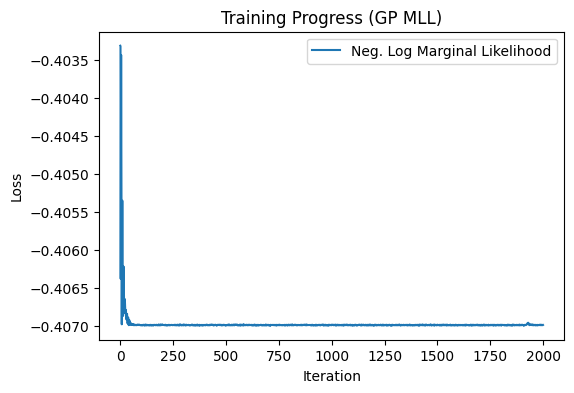

In [42]:
# Plot training progress
plt.figure(figsize=(6,4))
plt.plot(loss_history, label='Neg. Log Marginal Likelihood')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Progress (GP MLL)')
plt.legend()
plt.show()